In [ ]:
# Please specify the csv file path here
data_path = "./data/Sales.csv"

In [37]:
# Static variables used in code


In [38]:
from datetime import datetime
from typing import Any, Dict, List, Optional

import pandas as pd
from matplotlib import pyplot as plt

Determine Ground-truth label and Problem type 

In [ ]:
# Step 1 — ID Column Detection
def detect_id_columns(df):
    id_columns = []

    for col in df.columns:
        unique_ratio = df[col].nunique() / len(df)

        if unique_ratio > 0.95:
            id_columns.append(col)

        if "id" in col.lower():
            id_columns.append(col)

    return list(set(id_columns))

# Step 2 — Target Candidate Scoring
def score_target_candidates(df, id_columns):

    scores = {}

    for col in df.columns:

        if col in id_columns:
            continue

        score = 0
        unique_ratio = df[col].nunique() / len(df)

        # ---- Signal 1: Low Cardinality ----
        if unique_ratio < 0.1:
            score += 3
        elif unique_ratio < 0.3:
            score += 1

        # ---- Signal 2: Column Name ----
        target_keywords = ["target", "label", "class", "output", "result", "status", "y", "outcome"]

        if any(keyword in col.lower() for keyword in target_keywords):
            score += 4

        # ---- Signal 3: Last Column Bias ----
        if col == df.columns[-1]:
            score += 2

        # ---- Signal 4: Datatype Pattern ----
        if not pd.api.types.is_datetime64_any_dtype(df[col]):
            score += 2

        scores[col] = score

    return scores

# Step 3 — Select Best Candidate
def detect_target(df):

    id_columns = detect_id_columns(df)

    scores = score_target_candidates(df, id_columns)

    if len(scores) == 0:
        return None, scores

    predicted_target = max(scores, key=scores.get)

    if scores[predicted_target] == 0:
        return None, scores

    return predicted_target, scores


# Step 4 — Problem Type Detection (Connected)
def detect_problem_type(df, target):

    if target is None:
        return "Unsupervised"

    unique_values = df[target].nunique()

    if df[target].dtype == "object" or unique_values < 50:
        return "Classification"

    return "Regression"


# Step 5 — Explanation Output (HIGH MARK BOOST)
# This is extremely important. Your agent must explain reasoning.
def explain_target_choice(target, scores):

    print("\nTarget Detection Report")
    print("------------------------")

    if target is None:
        print("No reliable target detected. Dataset treated as unsupervised.")
        return

    print(f"Predicted Target Column: {target}")
    print("\nCandidate Scores:")

    for col, score in scores.items():
        print(f"{col}: {score}")


In [ ]:
# target, scores = detect_target(df)

# explain_target_choice(target, scores)

# problem_type = detect_problem_type(df, target)

# print("Detected Problem Type:", problem_type)


Signal Extraction

In [ ]:
def extract_dataset_overview(df):
    return {
        "dataset_size": len(df),
        "num_features": df.shape[1],
        "duplicate_count": df.duplicated().sum()
    }


def extract_feature_types(df):
    numerical = df.select_dtypes(include="number").columns.tolist()
    categorical = df.select_dtypes(include="object").columns.tolist()
    datetime = df.select_dtypes(include="datetime").columns.tolist()

    # ID detection
    id_features = []
    for col in df.columns:
        unique_ratio = df[col].nunique() / len(df)
        if unique_ratio > 0.95 or "id" in col.lower():
            id_features.append(col)

    return {
        "numerical_features": numerical,
        "categorical_features": categorical,
        "datetime_features": datetime,
        "id_features": id_features
    }



def extract_missing_signals(df):
    missing_percent = (df.isnull().sum() / len(df)) * 100

    return {
        "missing_percent": missing_percent.to_dict(),
        "columns_with_missing": missing_percent[missing_percent > 0].index.tolist(),
        "global_missing_severity": missing_percent.mean()
    }

def extract_target_signals(df):
    target, scores = detect_target(df)

    if target is None:
        return {
            "target_column": None,
            "problem_type": "Unsupervised",
            "target_cardinality": None
        }

    problem_type = detect_problem_type(df, target)

    return {
        "target_column": target,
        "problem_type": problem_type,
        "target_cardinality": df[target].nunique()
    }

def extract_imbalance_signals(df, target):
    if target is None:
        return {
            "class_distribution": None,
            "imbalance_ratio": None
        }

    distribution = df[target].value_counts(normalize=True)
    
    return {
        "class_distribution": distribution.to_dict(),
        "imbalance_ratio": distribution.max()
    }

def extract_cardinality_signals(df, categorical_cols):
    high_card_cols = []

    for col in categorical_cols:
        if df[col].nunique() > 20:
            high_card_cols.append(col)

    return {
        "high_cardinality": high_card_cols
    }

def extract_outlier_signals(df, numerical_cols):
    outlier_cols = []

    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]

        if len(outliers) > 0:
            outlier_cols.append(col)

    return {
        "outlier_columns": outlier_cols
    }

def extract_multicollinearity(df, numerical_cols):
    corr = df[numerical_cols].corr().abs()

    high_corr_pairs = []

    for i in range(len(corr.columns)):
        for j in range(i):
            if corr.iloc[i, j] > 0.8:
                pair = (corr.columns[i], corr.columns[j])
                high_corr_pairs.append(pair)

    return {
        "highly_correlated_pairs": high_corr_pairs
    }


def extract_dataset_signals(df):
    signals = {}

    # Overview
    signals.update(extract_dataset_overview(df))

    # Feature types
    feature_signals = extract_feature_types(df)
    signals.update(feature_signals)

    # Missing values
    signals.update(extract_missing_signals(df))

    # Target detection
    target_signals = extract_target_signals(df)
    signals.update(target_signals)

    # Imbalance
    signals.update(
        extract_imbalance_signals(df, signals["target_column"])
    )

    # Cardinality
    signals.update(
        extract_cardinality_signals(df, signals["categorical_features"])
    )

    # Outliers
    signals.update(
        extract_outlier_signals(df, signals["numerical_features"])
    )

    # Multicollinearity
    signals.update(
        extract_multicollinearity(df, signals["numerical_features"])
    )

    return signals


# signals = extract_dataset_signals(df)

# signals


Decision Engine

In [44]:
def action_decision_engine(signals):
    
    actions = {
        "eda": [],
        "preprocessing": [],
        "risks": [],
        "modelling": []
    }
    
    problem_type = signals["problem_type"]
    
    # --------------------------------
    # Problem Type Based Decisions
    # --------------------------------
    
    if problem_type == "Classification":
        actions["eda"].append("Plot target class distribution")
        actions["eda"].append("Analyse feature vs target relationships")
        actions["modelling"].append("Use classification models")
        
    elif problem_type == "Regression":
        actions["eda"].append("Analyse correlation between features and target")
        actions["eda"].append("Plot scatter plots of features vs target")
        actions["modelling"].append("Use regression models")
        
    else:
        actions["eda"].append("Analyse feature distributions")
        actions["eda"].append("Perform correlation analysis")
        actions["modelling"].append("Consider clustering or dimensionality reduction")

    # --------------------------------
    # Missing Value Decisions
    # --------------------------------
    
    missing_info = signals["missing_percent"]

    for col, pct in missing_info.items():
        
        if pct > 40:
            actions["risks"].append(f"{col} has very high missing values")
            actions["preprocessing"].append(f"Consider dropping or advanced imputation for {col}")
            
        elif pct > 0:
            actions["preprocessing"].append(f"Apply imputation for {col}")

    # --------------------------------
    # Imbalance Detection
    # --------------------------------
    
    if signals["imbalance_ratio"] is not None:
        if signals["imbalance_ratio"] > 0.7:
            actions["risks"].append("Severe class imbalance detected")
            actions["modelling"].append("Use F1-score or balanced metrics")
            actions["modelling"].append("Use stratified sampling")

    # --------------------------------
    # Dataset Size Risk
    # --------------------------------
    
    if signals["dataset_size"] < 500:
        actions["risks"].append("Small dataset — risk of overfitting")
        actions["modelling"].append("Prefer simpler models")

    # --------------------------------
    # Cardinality Detection
    # --------------------------------
    
    high_card_cols = signals["high_cardinality"]
    
    for col in high_card_cols:
        actions["risks"].append(f"{col} has high cardinality")
        actions["preprocessing"].append(f"Use appropriate encoding for {col}")

    # --------------------------------
    # Duplicate Handling
    # --------------------------------
    
    if signals["duplicate_count"] > 0:
        actions["preprocessing"].append("Remove duplicate rows")

    return actions


# signals = {
#     "problem_type": problem_type,
#     "missing_percent": missing_summary.to_dict()["Missing %"],
#     "imbalance_ratio": imbalance_ratio,
#     "dataset_size": len(df),
#     "high_cardinality": high_card_cols,
#     "duplicate_count": df.duplicated().sum()
# }


def print_agent_knowledge(actions):
    
    print("\n===== AGENT KNOWLEDGE REPORT =====\n")
    
    print("EDA Recommendations:")
    for item in actions["eda"]:
        print("-", item)

    print("\nPreprocessing Recommendations:")
    for item in actions["preprocessing"]:
        print("-", item)

    print("\nDetected Risks:")
    for item in actions["risks"]:
        print("-", item)

    print("\nModelling Strategy Suggestions:")
    for item in actions["modelling"]:
        print("-", item)


# actions = action_decision_engine(signals)
# print_agent_knowledge(actions)


EDA

In [46]:

def generate_basic_statistics(df):

    print("\n===== BASIC DATASET STATISTICS =====")
    display(df.describe(include='all'))


def plot_numerical_distributions(df, numerical_cols):

    if len(numerical_cols) == 0:
        return

    df[numerical_cols].hist(figsize=(12, 8))
    plt.suptitle("Numerical Feature Distributions")
    plt.show()


def plot_categorical_distributions(df, categorical_cols):

    for col in categorical_cols:
        plt.figure()
        df[col].value_counts().head(10).plot(kind="bar")
        plt.title(f"Top Categories: {col}")
        plt.show()


def classification_target_analysis(df, target):

    print("\n===== TARGET DISTRIBUTION =====")
    df[target].value_counts().plot(kind="bar")
    plt.title("Class Distribution")
    plt.show()


def regression_target_analysis(df, target):

    plt.figure()
    df[target].hist()
    plt.title("Target Distribution")
    plt.show()


def classification_feature_relationship(df, numerical_cols, target):

    for col in numerical_cols:
        plt.figure()
        df.boxplot(column=col, by=target)
        plt.title(f"{col} vs {target}")
        plt.show()


def regression_feature_relationship(df, numerical_cols, target):

    for col in numerical_cols:
        plt.figure()
        plt.scatter(df[col], df[target])
        plt.title(f"{col} vs {target}")
        plt.xlabel(col)
        plt.ylabel(target)
        plt.show()


def correlation_analysis(df, numerical_cols):

    if len(numerical_cols) < 2:
        return

    corr = df[numerical_cols].corr()

    plt.figure(figsize=(8,6))
    plt.imshow(corr)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Correlation Matrix")
    plt.show()


def generate_adaptive_eda(df, signals):

    print("\n==============================")
    print("ADAPTIVE EXPLORATORY DATA ANALYSIS")
    print("==============================")

    numerical_cols = signals["numerical_features"]
    categorical_cols = signals["categorical_features"]
    target = signals["target_column"]
    problem_type = signals["problem_type"]

    # Always run
    generate_basic_statistics(df)
    plot_numerical_distributions(df, numerical_cols)
    plot_categorical_distributions(df, categorical_cols)
    correlation_analysis(df, numerical_cols)

    # Conditional EDA
    if target is not None:

        if problem_type == "Classification":
            classification_target_analysis(df, target)
            classification_feature_relationship(df, numerical_cols, target)

        elif problem_type == "Regression":
            regression_target_analysis(df, target)
            regression_feature_relationship(df, numerical_cols, target)


# signals = extract_dataset_signals(df)

# generate_adaptive_eda(df, signals)



{'dataset_size': 30000, 'num_features': 18, 'duplicate_count': 0, 'numerical_features': ['size', 'base_price_usd', 'discount_percent', 'final_price_usd', 'units_sold', 'revenue_usd', 'customer_rating'], 'categorical_features': ['order_id', 'order_date', 'brand', 'model_name', 'category', 'gender', 'color', 'payment_method', 'sales_channel', 'country', 'customer_income_level'], 'datetime_features': [], 'id_features': ['order_id'], 'missing_percent': {'order_id': 0.0, 'order_date': 0.0, 'brand': 0.0, 'model_name': 0.0, 'category': 0.0, 'gender': 0.0, 'size': 0.0, 'color': 0.0, 'base_price_usd': 0.0, 'discount_percent': 0.0, 'final_price_usd': 0.0, 'units_sold': 0.0, 'revenue_usd': 0.0, 'payment_method': 0.0, 'sales_channel': 0.0, 'country': 0.0, 'customer_income_level': 0.0, 'customer_rating': 0.0}, 'columns_with_missing': [], 'global_missing_severity': 0.0, 'target_column': 'category', 'problem_type': 'Classification', 'target_cardinality': 5, 'class_distribution': {'Basketball': 0.2024

,order_id,order_date,brand,model_name,category,gender,size,color,base_price_usd,discount_percent,final_price_usd,units_sold,revenue_usd,payment_method,sales_channel,country,customer_income_level,customer_rating
count,30000,30000,30000,30000,30000,30000,30000.000000,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000,30000,30000,30000,30000.000000
unique,30000,3287,6,899,5,3,NaN,5,NaN,NaN,NaN,NaN,NaN,4,2,6,3,NaN
top,ORD100000,2022-03-07,ASICS,Model-863,Basketball,Men,NaN,Grey,NaN,NaN,NaN,NaN,NaN,Bank Transfer,Retail Store,UAE,High,NaN
freq,1,21,5132,53,6074,10075,NaN,6046,NaN,NaN,NaN,NaN,NaN,7686,15009,5118,10059,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,8.500867,NaN,139.634633,13.332167,121.029035,2.500200,302.714948,NaN,NaN,NaN,NaN,4.001543
std,NaN,NaN,NaN,NaN,NaN,NaN,1.710896,NaN,46.062549,9.864198,42.511586,1.121149,179.149272,NaN,NaN,NaN,NaN,0.577546
min,NaN,NaN,NaN,NaN,NaN,NaN,6.000000,NaN,60.000000,0.000000,42.000000,1.000000,42.000000,NaN,NaN,NaN,NaN,3.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,100.000000,5.000000,85.000000,1.000000,156.750000,NaN,NaN,NaN,NaN,3.500000
50%,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,140.000000,10.000000,119.200000,3.000000,268.200000,NaN,NaN,NaN,NaN,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,180.000000,20.000000,153.600000,4.000000,414.000000,NaN,NaN,NaN,NaN,4.500000


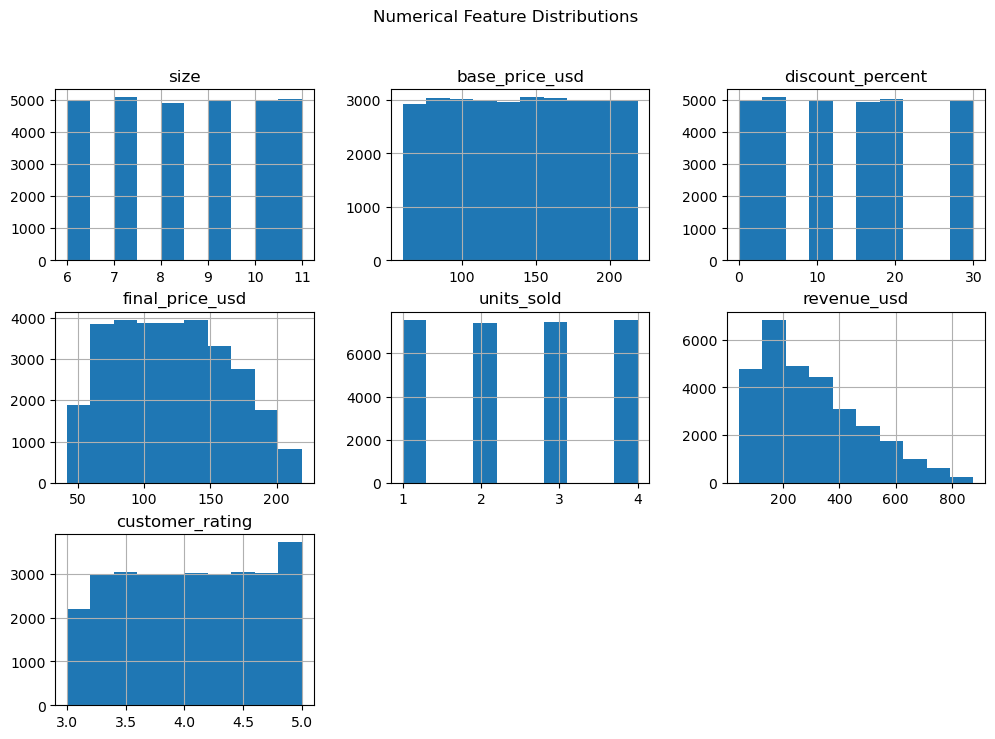

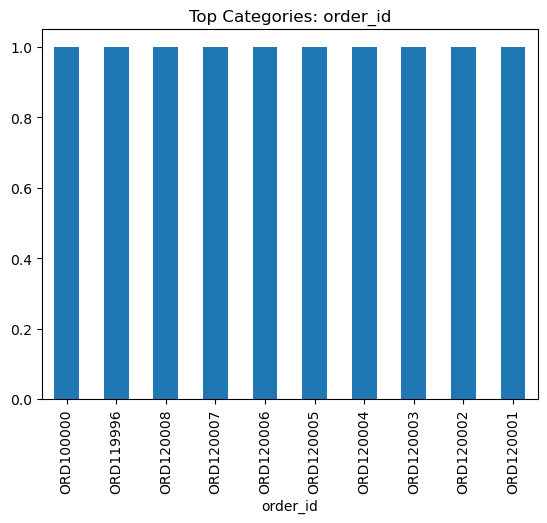

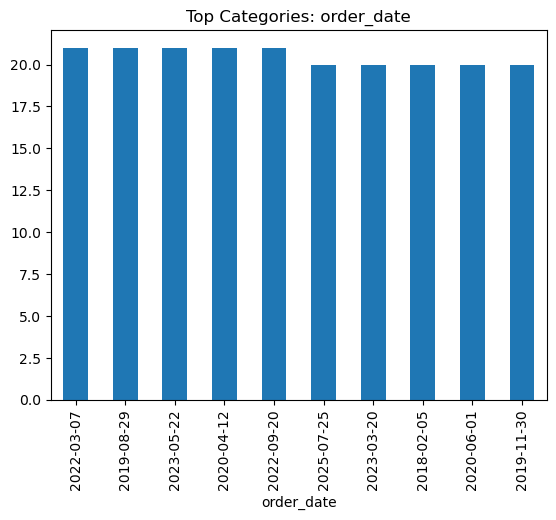

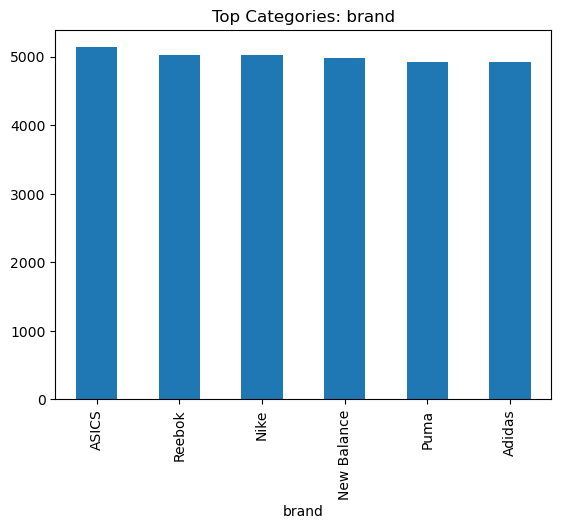

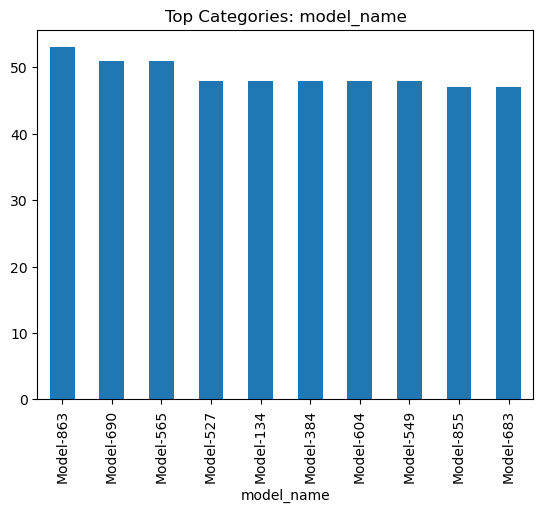

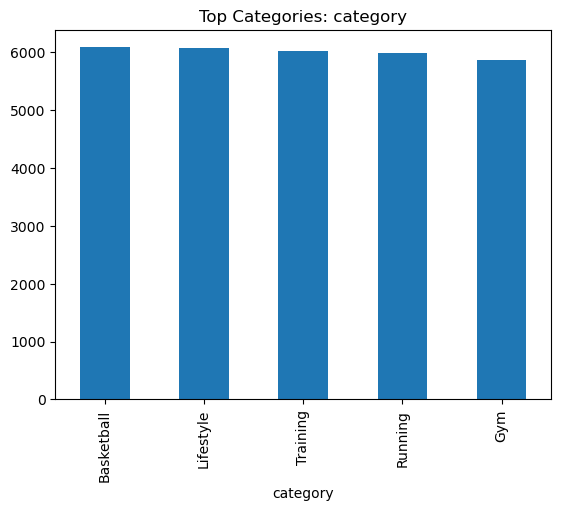

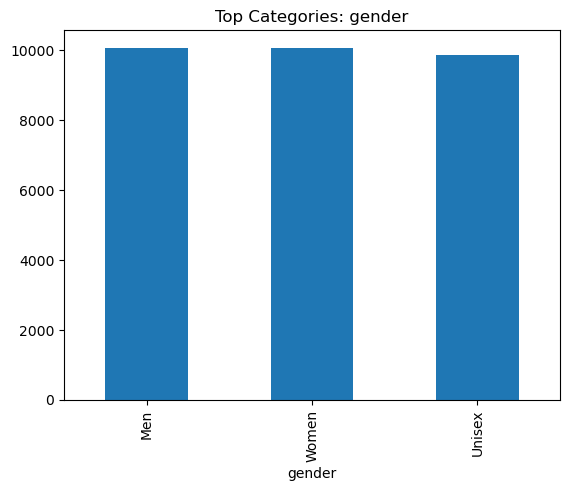

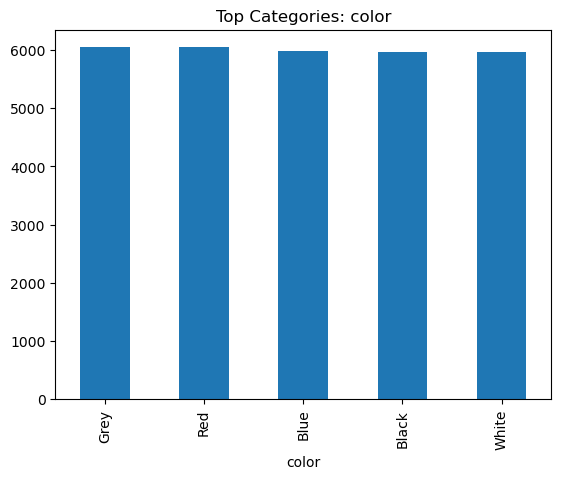

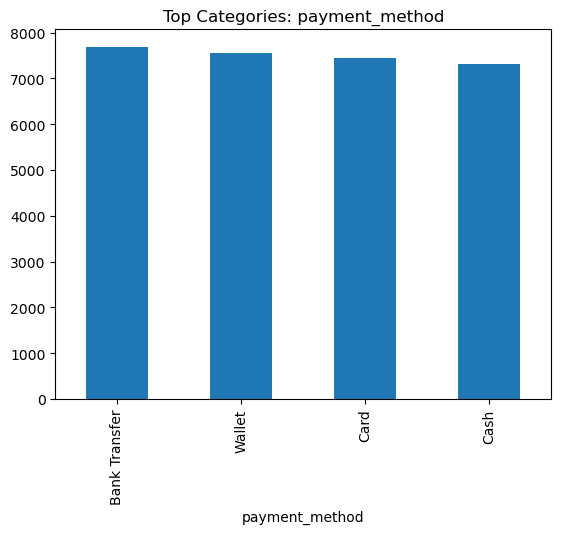

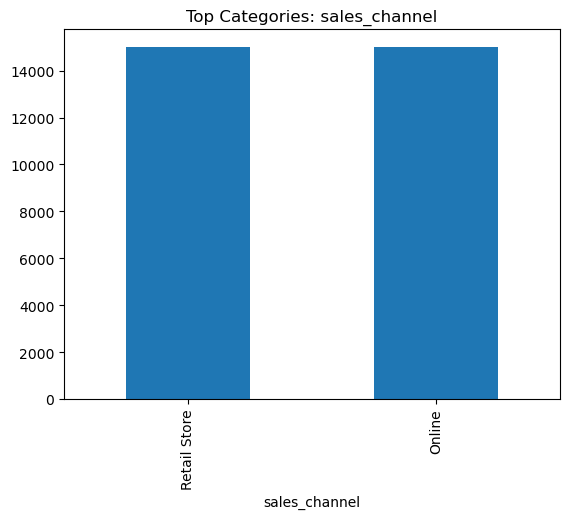

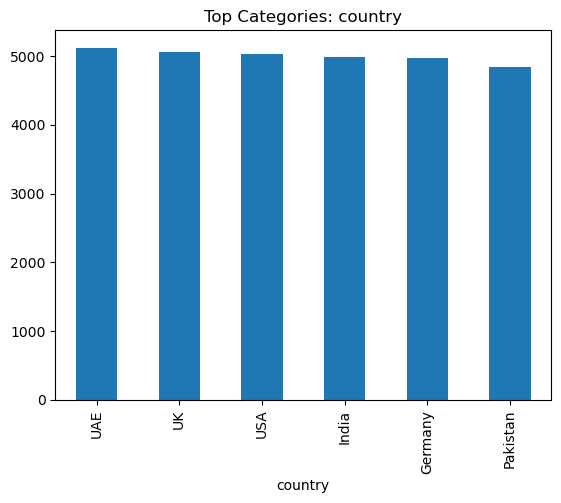

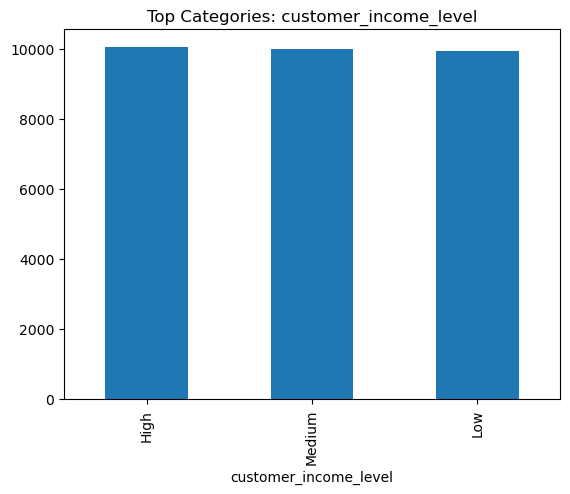

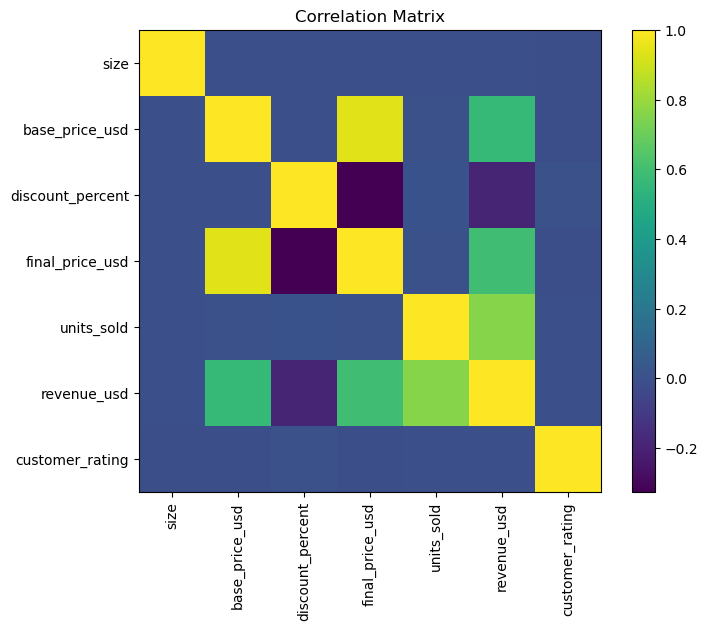


===== TARGET DISTRIBUTION =====


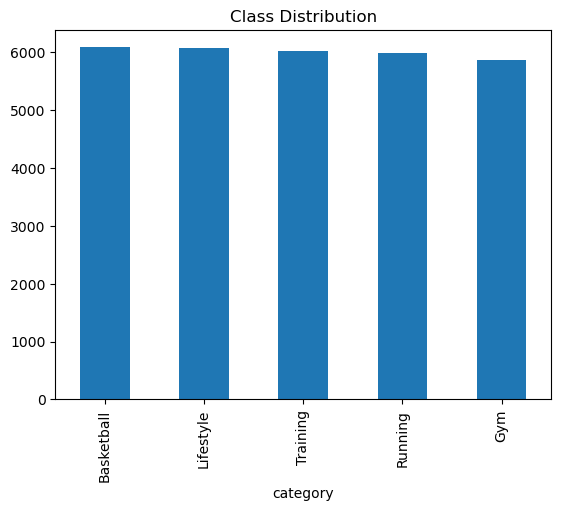

<Figure size 640x480 with 0 Axes>

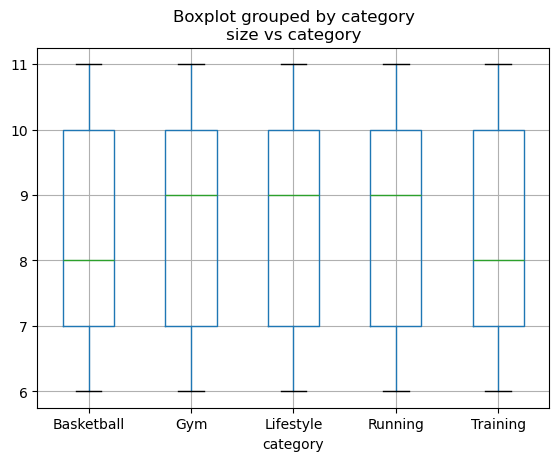

<Figure size 640x480 with 0 Axes>

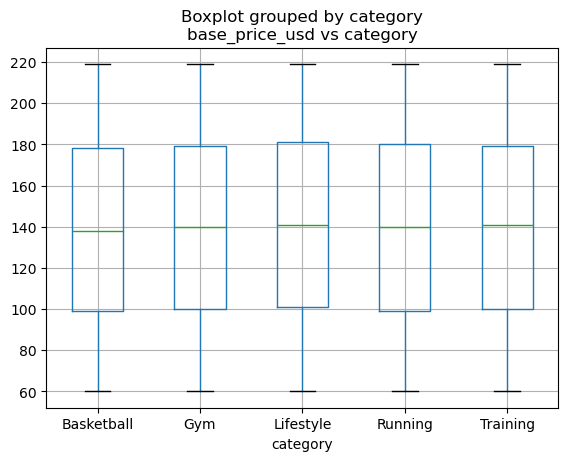

<Figure size 640x480 with 0 Axes>

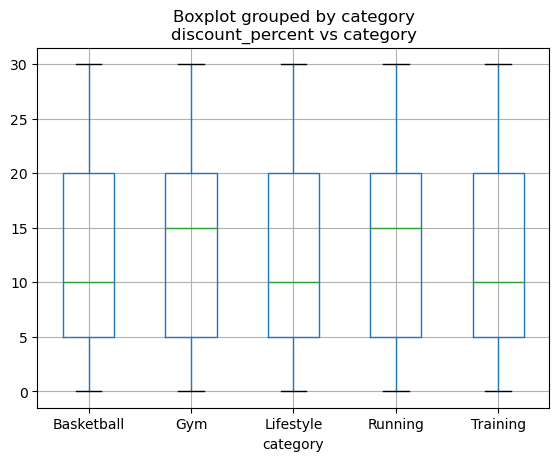

<Figure size 640x480 with 0 Axes>

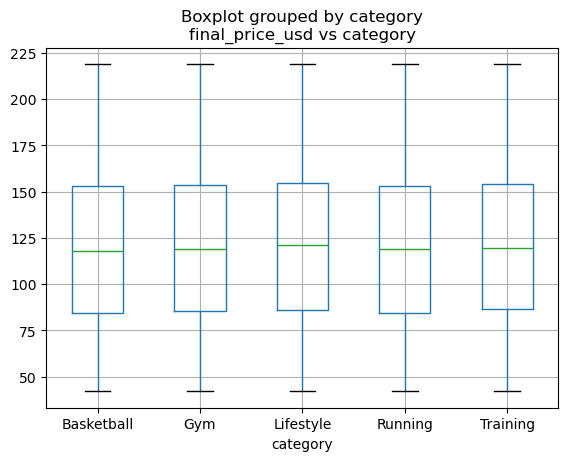

<Figure size 640x480 with 0 Axes>

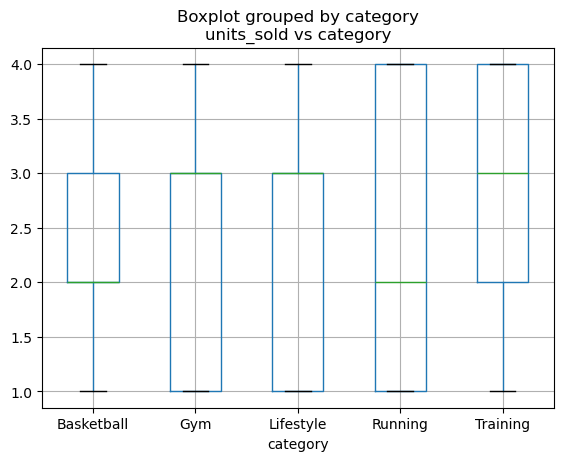

<Figure size 640x480 with 0 Axes>

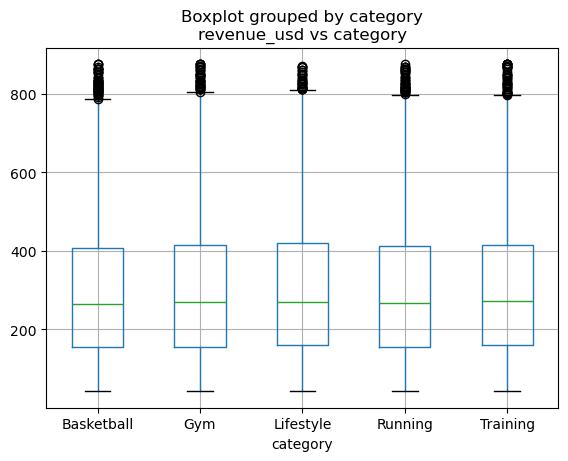

<Figure size 640x480 with 0 Axes>

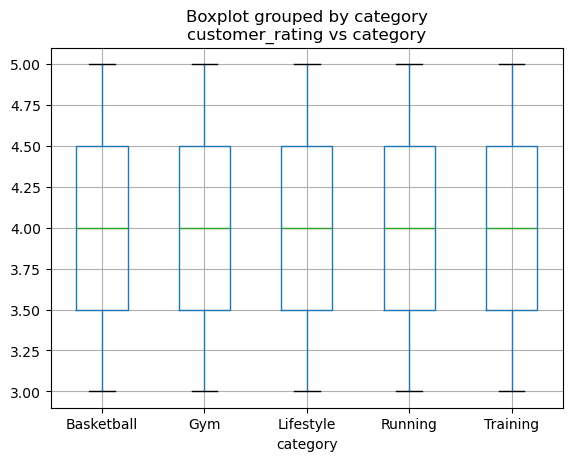


===== AGENT KNOWLEDGE REPORT =====

EDA Recommendations:
- Plot target class distribution
- Analyse feature vs target relationships

Preprocessing Recommendations:
- Use appropriate encoding for order_id
- Use appropriate encoding for order_date
- Use appropriate encoding for model_name

Detected Risks:
- order_id has high cardinality
- order_date has high cardinality
- model_name has high cardinality

Modelling Strategy Suggestions:
- Use classification models


In [ ]:
df = pd.read_csv(data_path)

signals = extract_dataset_signals(df)
print(signals)

generate_adaptive_eda(df, signals)

actions = action_decision_engine(signals)
print_agent_knowledge(actions)